# Exercise: Cambridge Crime Dataset

**Bharani Amarnath - Datamites: Batch 09062025-0830 | Course: CDS, AIE**

### Initial configuration / Autoreload extensions

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
!pip install kagglehub

In [3]:
!pip install --upgrade ipywidgets

### Import required libraries

In [4]:
#System libs
import os
import array
import math

#Misc libs
import pandas as pd
import kagglehub as kh
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Download dataset from kaggle repository using kagglehub

In [5]:
dpath = kh.dataset_download("melissamonfared/cambridge-crime-data-2009-2024")
print("Path to dataset files:", dpath)

Path to dataset files: C:\Users\bharani\.cache\kagglehub\datasets\melissamonfared\cambridge-crime-data-2009-2024\versions\1


### Read csv dataset with pandas

In [6]:
dset = pd.read_csv("Crime_Reports_20240701.csv")

### Print shape / count of csv dataset

In [7]:
dset.shape

(95923, 7)

### Print all columns in csv dataset

In [8]:
dset.keys()

Index(['File Number', 'Date of Report', 'Crime Date Time', 'Crime',
       'Reporting Area', 'Neighborhood', 'Location'],
      dtype='object')

In [9]:
dset.columns

Index(['File Number', 'Date of Report', 'Crime Date Time', 'Crime',
       'Reporting Area', 'Neighborhood', 'Location'],
      dtype='object')

### Print entire csv dataset

In [10]:
print(dset)

      File Number          Date of Report  \
0      2009-01323  02/21/2009 09:53:00 AM   
1      2009-01324  02/21/2009 09:59:00 AM   
2      2009-01327  02/21/2009 12:32:00 PM   
3      2009-01331  02/21/2009 03:05:00 PM   
4      2009-01346  02/22/2009 05:02:00 AM   
...           ...                     ...   
95918  2024-03755  05/07/2024 01:13:00 PM   
95919  2024-03756  05/07/2024 02:41:00 PM   
95920  2024-03777  05/07/2024 08:13:00 PM   
95921  2024-03806  05/08/2024 04:09:00 PM   
95922  2024-03824  05/09/2024 10:23:00 AM   

                           Crime Date Time               Crime  \
0                 02/21/2009 09:20 - 09:30             Threats   
1      02/20/2009 22:30 - 02/21/2009 10:00          Auto Theft   
2      02/19/2009 21:00 - 02/21/2009 12:00         Hit and Run   
3                 02/21/2009 15:00 - 15:10      Larceny (Misc)   
4                         02/22/2009 05:02                 OUI   
...                                    ...                 ... 

### Print specific column in csv dataset

In [11]:
print(dset['File Number'])

0        2009-01323
1        2009-01324
2        2009-01327
3        2009-01331
4        2009-01346
            ...    
95918    2024-03755
95919    2024-03756
95920    2024-03777
95921    2024-03806
95922    2024-03824
Name: File Number, Length: 95923, dtype: object


### Create pandas dataframe from csv dataset

In [12]:
dsf = pd.DataFrame(dset)

### Print dataframe / Limit: 5

In [13]:
print(dsf[:5])

  File Number          Date of Report                      Crime Date Time  \
0  2009-01323  02/21/2009 09:53:00 AM             02/21/2009 09:20 - 09:30   
1  2009-01324  02/21/2009 09:59:00 AM  02/20/2009 22:30 - 02/21/2009 10:00   
2  2009-01327  02/21/2009 12:32:00 PM  02/19/2009 21:00 - 02/21/2009 12:00   
3  2009-01331  02/21/2009 03:05:00 PM             02/21/2009 15:00 - 15:10   
4  2009-01346  02/22/2009 05:02:00 AM                     02/22/2009 05:02   

            Crime  Reporting Area     Neighborhood  \
0         Threats           105.0   East Cambridge   
1      Auto Theft          1109.0  North Cambridge   
2     Hit and Run          1109.0  North Cambridge   
3  Larceny (Misc)          1303.0  Strawberry Hill   
4             OUI           105.0   East Cambridge   

                            Location  
0         100 OTIS ST, Cambridge, MA  
1      400 RINDGE AVE, Cambridge, MA  
2      400 RINDGE AVE, Cambridge, MA  
3      0 NORUMBEGA ST, Cambridge, MA  
4  FIFTH ST

### Plot histogram / Column: Neighborhood by count

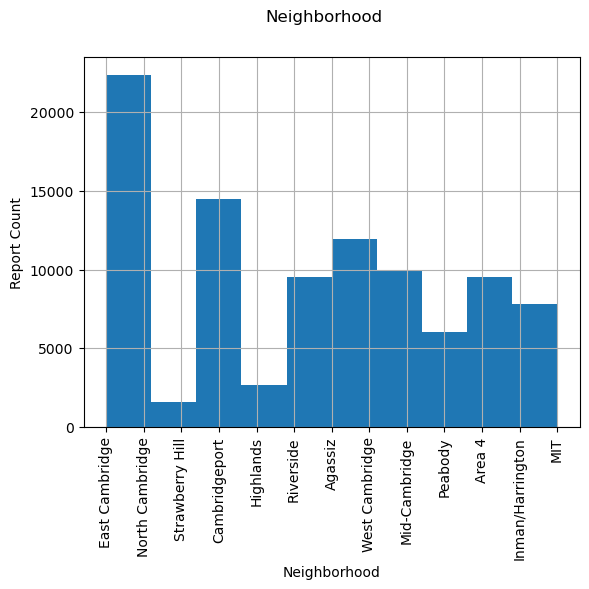

In [14]:
dcol = "Neighborhood"
dsf[dcol].hist()
plt.suptitle(dcol)
plt.xlabel("Neighborhood")
plt.ylabel("Report Count")
plt.xticks(rotation=90)
plt.show()

### Filtered dataset histogram / Columns: Crime, Neighborhood

      File Number          Date of Report           Crime Date Time  \
161    2009-00225  01/09/2009 09:18:00 AM  01/09/2009 08:30 - 08:45   
1575   2009-04425  06/19/2009 09:17:00 AM  06/19/2009 08:55 - 09:00   
1766   2009-05180  07/17/2009 08:10:00 PM  07/17/2009 19:55 - 20:10   
1890   2009-05416  07/25/2009 11:21:00 PM  07/25/2009 23:20 - 23:21   
2357   2009-01939  03/17/2009 05:38:00 PM  03/17/2009 17:30 - 17:37   
...           ...                     ...                       ...   
92617  2023-11335  12/12/2023 05:18:00 PM  12/12/2023 17:15 - 17:18   
93459  2024-02222  03/18/2024 08:57:00 PM          03/18/2024 20:56   
94524  2024-04137  05/19/2024 07:08:00 PM          05/19/2024 19:07   
94837  2024-04352  05/25/2024 03:53:00 PM          05/25/2024 15:52   
95220  2024-02940  04/11/2024 06:46:00 PM  04/11/2024 17:35 - 18:45   

                    Crime  Reporting Area    Neighborhood  \
161    Aggravated Assault           105.0  East Cambridge   
1575   Aggravated Assault

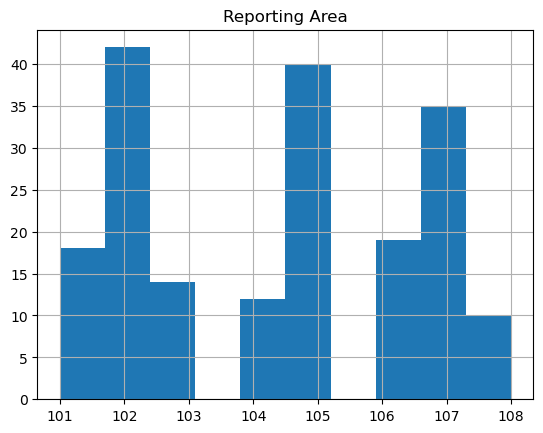

In [15]:
cdsf = dsf[dsf["Crime"] == "Aggravated Assault"]
cdsf = cdsf[cdsf["Neighborhood"] == "East Cambridge"]
print(cdsf)
cdsf.hist()
plt.show()

### Print limit: 10, column: Data of Report

In [16]:
print(dsf["Date of Report"][:10])

0    02/21/2009 09:53:00 AM
1    02/21/2009 09:59:00 AM
2    02/21/2009 12:32:00 PM
3    02/21/2009 03:05:00 PM
4    02/22/2009 05:02:00 AM
5    02/22/2009 09:39:00 PM
6    02/23/2009 10:19:00 AM
7    02/23/2009 11:24:00 AM
8    02/23/2009 08:16:00 PM
9    02/24/2009 09:02:00 AM
Name: Date of Report, dtype: object


### Filter dataset by specific values in column: Neighborhood

In [17]:
fds = dsf.loc[dsf["Neighborhood"].isin(["East Cambridge", "North Cambridge"])]

In [18]:
print(fds)

      File Number          Date of Report  \
0      2009-01323  02/21/2009 09:53:00 AM   
1      2009-01324  02/21/2009 09:59:00 AM   
2      2009-01327  02/21/2009 12:32:00 PM   
4      2009-01346  02/22/2009 05:02:00 AM   
5      2009-01357  02/22/2009 09:39:00 PM   
...           ...                     ...   
95696  2024-03095  04/17/2024 07:09:00 AM   
95733  2024-01263  02/15/2024 02:53:00 PM   
95749  2024-02006  03/11/2024 09:43:00 AM   
95826  2024-02811  04/08/2024 12:21:00 AM   
95875  2024-03409  04/27/2024 09:56:00 AM   

                           Crime Date Time                   Crime  \
0                 02/21/2009 09:20 - 09:30                 Threats   
1      02/20/2009 22:30 - 02/21/2009 10:00              Auto Theft   
2      02/19/2009 21:00 - 02/21/2009 12:00             Hit and Run   
4                         02/22/2009 05:02                     OUI   
5                 02/22/2009 21:39 - 21:45      Aggravated Assault   
...                                    

### Get filtered dataset shape / count

In [19]:
fds.shape[0]

22361

### Group dataset by column: Crime

In [20]:
gds = dsf.groupby(['Crime'])

In [21]:
gdsd = gds.count()
gdsd.shape

(54, 6)

In [22]:
print(gdsd.sort_values(by="File Number"))

                        File Number  Date of Report  Crime Date Time  \
Crime                                                                  
Gambling                          4               4                4   
Violation of R.O.                 7               7                7   
Domestic Dispute                 10              10               10   
Homicide                         21              21               21   
Kidnapping                       34              34               34   
Stalking                         41              41               41   
Prostitution                     73              73               73   
Liquor Possession/Sale           74              74               74   
Peeping & Spying                 83              83               83   
Sex Offender Violation           94              94               94   
Annoying & Accosting            148             148              148   
Arson                           148             148             

### Display dataset head rows

In [23]:
dset.head

<bound method NDFrame.head of       File Number          Date of Report  \
0      2009-01323  02/21/2009 09:53:00 AM   
1      2009-01324  02/21/2009 09:59:00 AM   
2      2009-01327  02/21/2009 12:32:00 PM   
3      2009-01331  02/21/2009 03:05:00 PM   
4      2009-01346  02/22/2009 05:02:00 AM   
...           ...                     ...   
95918  2024-03755  05/07/2024 01:13:00 PM   
95919  2024-03756  05/07/2024 02:41:00 PM   
95920  2024-03777  05/07/2024 08:13:00 PM   
95921  2024-03806  05/08/2024 04:09:00 PM   
95922  2024-03824  05/09/2024 10:23:00 AM   

                           Crime Date Time               Crime  \
0                 02/21/2009 09:20 - 09:30             Threats   
1      02/20/2009 22:30 - 02/21/2009 10:00          Auto Theft   
2      02/19/2009 21:00 - 02/21/2009 12:00         Hit and Run   
3                 02/21/2009 15:00 - 15:10      Larceny (Misc)   
4                         02/22/2009 05:02                 OUI   
...                              

### Columns datatype in dataset

In [24]:
dset.dtypes

File Number         object
Date of Report      object
Crime Date Time     object
Crime               object
Reporting Area     float64
Neighborhood        object
Location            object
dtype: object

In [25]:
dset["Date of Report"] = pd.to_datetime(dset["Date of Report"])

### Columns updated datatype in dataset

In [26]:
dset.dtypes

File Number                object
Date of Report     datetime64[ns]
Crime Date Time            object
Crime                      object
Reporting Area            float64
Neighborhood               object
Location                   object
dtype: object

### Dataset info

In [27]:
dset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95923 entries, 0 to 95922
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   File Number      95923 non-null  object        
 1   Date of Report   95923 non-null  datetime64[ns]
 2   Crime Date Time  95912 non-null  object        
 3   Crime            95923 non-null  object        
 4   Reporting Area   95915 non-null  float64       
 5   Neighborhood     95915 non-null  object        
 6   Location         95628 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 5.1+ MB


### Describe dataset / By Stats

In [28]:
dset.describe()

,Date of Report,Reporting Area
count,95923,95915.000000
mean,2016-08-18 03:55:46.387831808,632.548892
min,2009-01-01 00:39:00,101.000000
25%,2012-08-24 14:19:30,406.000000
50%,2016-06-06 17:51:00,604.000000
75%,2020-09-12 08:22:00,912.000000
max,2024-05-31 22:04:00,1304.000000
std,NaN,336.783879


### Check duplicate rows

In [29]:
dup_rows = dset[dset.duplicated()]
if not dup_rows.empty:
    print("duplicate rows:")
    print(dup_rows)
else:
    print("No duplicate rows")

No duplicate rows


### Check null values in all columns

In [30]:
for col in dset.columns:
    nc = dset[col].isnull().sum()
    print(f"Column {col} has {nc} null values")


Column File Number has 0 null values
Column Date of Report has 0 null values
Column Crime Date Time has 11 null values
Column Crime has 0 null values
Column Reporting Area has 8 null values
Column Neighborhood has 8 null values
Column Location has 295 null values


### Drop rows with null values in Column: Location

In [31]:
# dset.dropna(subset=["Location"], inplace=True)

### Count rows by group column: Location

In [32]:
dset["Location"].value_counts()

Location
100 CAMBRIDGESIDE PL, Cambridge, MA            3133
600 MASSACHUSETTS AVE, Cambridge, MA           2780
200 Alewife Brook Pky, Cambridge, MA           1287
500 MASSACHUSETTS AVE, Cambridge, MA           1044
0 WHITE ST, Cambridge, MA                       966
                                               ... 
FRONT ST & Massachusetts Ave, Cambridge, MA       1
Harding St & Cambridge St, Cambridge, MA          1
Oxford St & Frost St, Cambridge, MA               1
FARRAR ST & IRVING ST, Cambridge, MA              1
COLUMBIA ST & Harvard St, Cambridge, MA           1
Name: count, Length: 5143, dtype: int64

### Filter dataset by column: Crime / Homicide Associated

In [33]:
dset = dset[dset['Crime'].isin(['Homicide', 'Simple Assault', 'Aggravated Assault', 'Threats', 'Trespassing', 'Stalking'])]
display(dset)

,File Number,Date of Report,Crime Date Time,Crime,Reporting Area,Neighborhood,Location
0,2009-01323,2009-02-21 09:53:00,02/21/2009 09:20 - 09:30,Threats,105.0,East Cambridge,"100 OTIS ST, Cambridge, MA"
5,2009-01357,2009-02-22 21:39:00,02/22/2009 21:39 - 21:45,Aggravated Assault,1109.0,North Cambridge,"400 RINDGE AVE, Cambridge, MA"
13,2009-01423,2009-02-25 12:16:00,02/24/2009 12:15 - 12:30,Simple Assault,501.0,Cambridgeport,"500 Massachusetts Ave, Cambridge, MA"
17,2009-01436,2009-02-25 17:52:00,02/20/2009 00:10,Simple Assault,106.0,East Cambridge,"0 FULKERSON ST, Cambridge, MA"
24,2009-01475,2009-02-26 10:10:00,02/26/2009 10:10,Threats,1109.0,North Cambridge,"400 RINDGE AVE, Cambridge, MA"
...,...,...,...,...,...,...,...
95852,2024-04482,2024-05-29 22:37:00,05/29/2024 22:36,Simple Assault,504.0,Cambridgeport,"BROOKLINE ST & GREEN ST, Cambridge, MA"
95856,2024-04506,2024-05-30 11:40:00,05/30/2024 10:49,Threats,903.0,Peabody,"1700 MASSACHUSETTS AVE, Cambridge, MA"
95861,2024-03280,2024-04-23 13:52:00,04/23/2024 07:15 - 08:15,Threats,1204.0,Highlands,"200 Alewife Brook Pky, Cambridge, MA"
95878,2024-03432,2024-04-28 09:53:00,04/28/2024 09:45 - 09:53,Simple Assault,1204.0,Highlands,"0 NEW ST, Cambridge, MA"


### Count rows by filtered group column: Crime

In [34]:
dset["Crime"].value_counts()

Crime
Simple Assault        4205
Threats               2775
Aggravated Assault    2402
Trespassing            747
Stalking                41
Homicide                21
Name: count, dtype: int64

### Count rows by group column: Reporting Area

In [35]:
dset["Reporting Area"].value_counts()

Reporting Area
501.0     990
1002.0    689
411.0     431
701.0     365
708.0     365
         ... 
1015.0      3
410.0       3
906.0       3
1011.0      2
109.0       1
Name: count, Length: 117, dtype: int64

### Filter column: Reporting Area / Count > 0

In [36]:
dset = dset.groupby("Reporting Area").filter(lambda x: len(x) > 0)
dset["Reporting Area"].value_counts()

Reporting Area
501.0     990
1002.0    689
411.0     431
701.0     365
708.0     365
         ... 
1015.0      3
410.0       3
906.0       3
1011.0      2
109.0       1
Name: count, Length: 117, dtype: int64

### Updated count column: Crime / Filter: Reporting Area

In [37]:
dset["Crime"].value_counts()

Crime
Simple Assault        4205
Threats               2775
Aggravated Assault    2402
Trespassing            747
Stalking                41
Homicide                21
Name: count, dtype: int64

### Plot line graph / Crime by Reporting Area

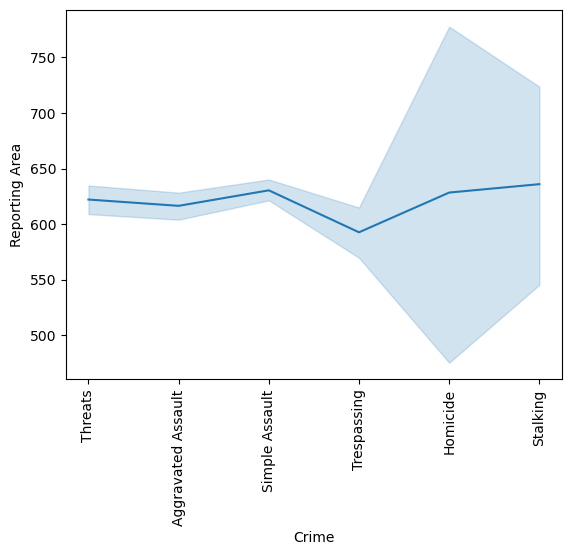

In [38]:
sns.lineplot(x="Crime", y="Reporting Area",data=dset)
plt.xticks(rotation=90)
plt.show()

### Group count column: Crime / Filter: Homicide Associated

In [39]:
gcdset = dset.groupby("Crime").count()["File Number"]
print(gcdset)

Crime
Aggravated Assault    2402
Homicide                21
Simple Assault        4205
Stalking                41
Threats               2775
Trespassing            747
Name: File Number, dtype: int64


### Plot line graph / Crime type by count

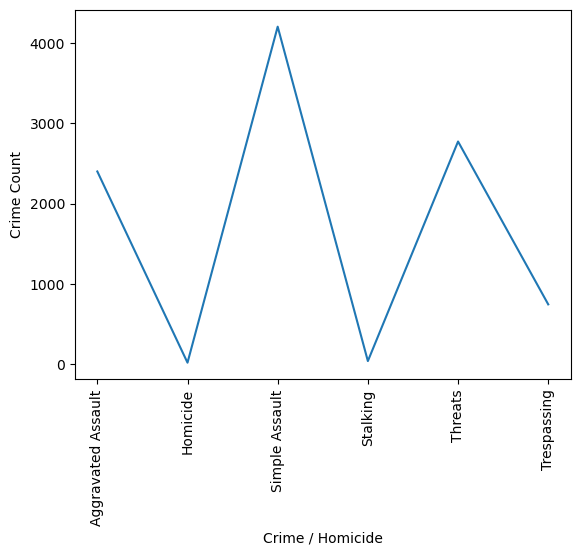

In [40]:
gcdset = pd.DataFrame(gcdset)
sns.lineplot(x="Crime",y="File Number",data=gcdset)
plt.xlabel("Crime / Homicide")
plt.ylabel("Crime Count")
plt.xticks(rotation=90)
plt.show()

### Filter dataset by specific month

In [41]:
dset[dset["Date of Report"].dt.month == 6]

,File Number,Date of Report,Crime Date Time,Crime,Reporting Area,Neighborhood,Location
630,2009-04370,2009-06-17 16:38:00,06/17/2009 16:35 - 16:38,Simple Assault,107.0,East Cambridge,"CAMBRIDGE ST & SECOND ST, Cambridge, MA"
689,2009-04231,2009-06-12 11:33:00,05/24/2009 15:00,Simple Assault,1108.0,North Cambridge,"100 CLIFTON ST, Cambridge, MA"
701,2009-04322,2009-06-16 03:05:00,06/16/2009 03:00 - 03:05,Homicide,1108.0,North Cambridge,"300 RINDGE AVE, Cambridge, MA"
990,2009-04178,2009-06-10 15:48:00,06/10/2009 15:45 - 15:48,Threats,403.0,Area 4,"100 HARVARD ST, Cambridge, MA"
996,2009-04208,2009-06-11 14:15:00,06/11/2009 11:08 - 11:12,Threats,905.0,Peabody,"1800 Massachusetts Ave, Cambridge, MA"
...,...,...,...,...,...,...,...
90101,2023-05662,2023-06-26 09:00:00,06/01/2020 09:04 - 06/26/2023 08:59,Threats,613.0,Mid-Cambridge,"1500 CAMBRIDGE ST, Cambridge, MA"
90628,2023-08599,2022-06-07 00:09:00,06/07/2022 00:09,Simple Assault,802.0,Agassiz,"1500 MASSACHUSETTS AVE, Cambridge, MA"
90762,2023-05400,2023-06-18 10:09:00,06/18/2023 10:09,Simple Assault,301.0,Inman/Harrington,"WINDSOR ST & Cambridge St, Cambridge, MA"
91004,2023-05440,2023-06-19 17:19:00,06/19/2023 17:18,Aggravated Assault,405.0,Area 4,"Washington St & Windsor St, Cambridge, MA"


### Group count dataset by each month

In [42]:
gmdset = dset.groupby(dset["Date of Report"].dt.month).count()
print(gmdset)

                File Number  Date of Report  Crime Date Time  Crime  \
Date of Report                                                        
1                       749             749              749    749   
2                       779             779              779    779   
3                       831             831              831    831   
4                       840             840              840    840   
5                       926             926              926    926   
6                       886             886              886    886   
7                       939             939              939    939   
8                       868             868              868    868   
9                       913             913              913    913   
10                      866             866              866    866   
11                      792             792              792    792   
12                      802             802              802    802   

     

### Plot line graph / Crime count by each month

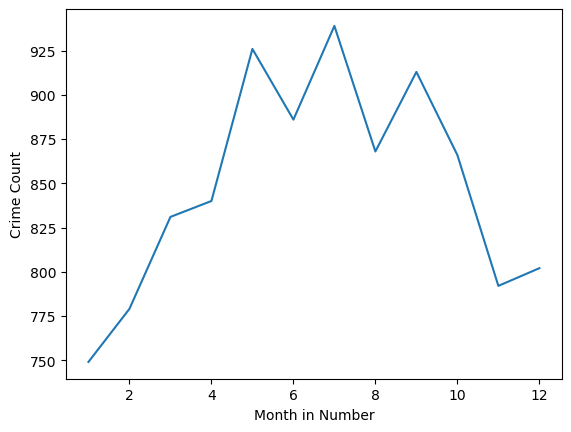

In [43]:
sns.lineplot(x=gmdset.index,y="File Number", data=gmdset)
plt.xlabel("Month in Number")
plt.ylabel("Crime Count")
plt.show()

### Calculate mean crime count for all months

In [44]:
gmdset["Date of Report"].mean()

849.25

### Group count by columns: Months, Crime

In [45]:
gcmdset = dset.groupby([dset["Date of Report"].dt.month, "Crime"]).count()["Date of Report"]
print(gcmdset)

Date of Report  Crime             
1               Aggravated Assault    170
                Homicide                3
                Simple Assault        280
                Stalking                3
                Threats               211
                                     ... 
12              Homicide                1
                Simple Assault        323
                Stalking                1
                Threats               232
                Trespassing            75
Name: Date of Report, Length: 71, dtype: int64


### Plot line graph / Crime count by each month per crime

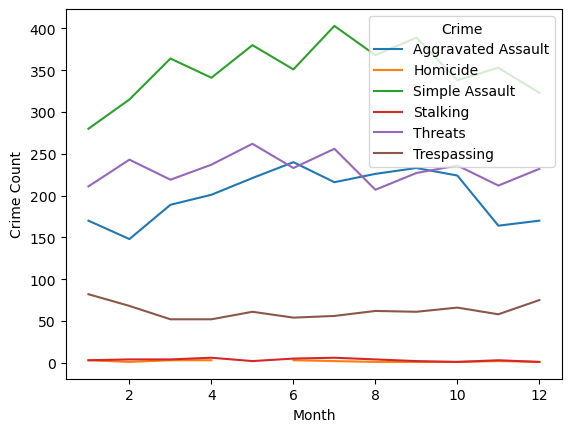

In [46]:
gcmdset.unstack().plot()
plt.xlabel("Month")
plt.ylabel("Crime Count")
plt.show()

### Plot line graph / Crime count by neighborhood, crime type in each month

In [47]:
gcmndset = dset.groupby([dset["Date of Report"].dt.month, "Neighborhood", "Crime"]).count()["File Number"]
print(gcmndset)

Date of Report  Neighborhood     Crime             
1               Agassiz          Aggravated Assault     3
                                 Simple Assault         3
                                 Threats                3
                                 Trespassing            1
                Area 4           Aggravated Assault    16
                                                       ..
12              Strawberry Hill  Threats                4
                West Cambridge   Aggravated Assault     8
                                 Simple Assault        39
                                 Threats               18
                                 Trespassing            3
Name: File Number, Length: 661, dtype: int64


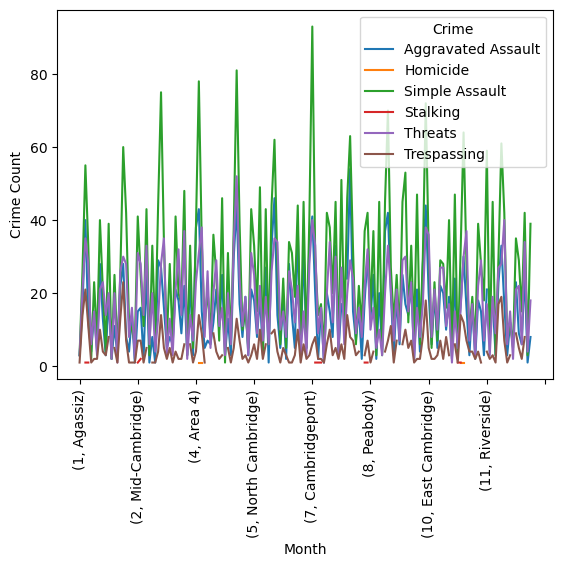

In [48]:
gcmndset.unstack().plot()
plt.xlabel("Month")
plt.ylabel("Crime Count")
plt.xticks(rotation=90)
plt.show()

In [49]:
gcndset = dset.groupby([dset["Date of Report"].dt.month, "Neighborhood"]).count()["File Number"]
print(gcndset)

Date of Report  Neighborhood   
1               Agassiz             10
                Area 4              77
                Cambridgeport      152
                East Cambridge      85
                Highlands           14
                                  ... 
12              North Cambridge     65
                Peabody             29
                Riverside          110
                Strawberry Hill      9
                West Cambridge      68
Name: File Number, Length: 156, dtype: int64


### Plot line graph / Crime count by each month & neighborhood

                                File Number
Date of Report Neighborhood                
1              Agassiz                   10
               Area 4                    77
               Cambridgeport            152
               East Cambridge            85
               Highlands                 14
...                                     ...
12             North Cambridge           65
               Peabody                   29
               Riverside                110
               Strawberry Hill            9
               West Cambridge            68

[156 rows x 1 columns]


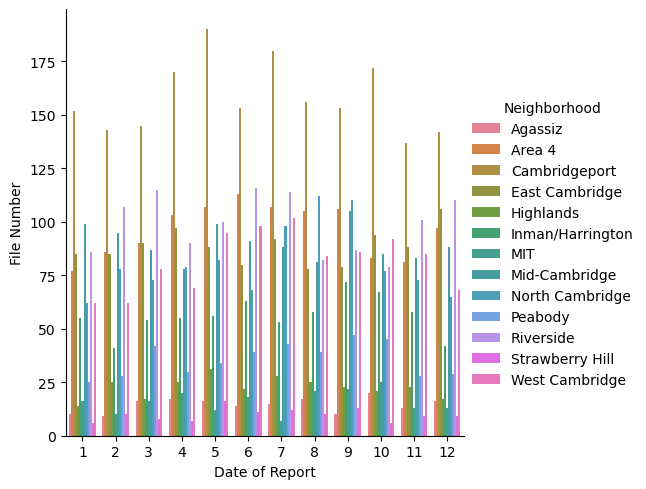

In [50]:
gcndset = pd.DataFrame(gcndset)
print(gcndset)
sns.catplot(data=gcndset, kind="bar",x="Date of Report",y="File Number",hue="Neighborhood")
plt.show()

                                                   File Number
Date of Report Neighborhood    Crime                          
1              Agassiz         Aggravated Assault            3
                               Simple Assault                3
                               Threats                       3
                               Trespassing                   1
               Area 4          Aggravated Assault           16
...                                                        ...
12             Strawberry Hill Threats                       4
               West Cambridge  Aggravated Assault            8
                               Simple Assault               39
                               Threats                      18
                               Trespassing                   3

[661 rows x 1 columns]


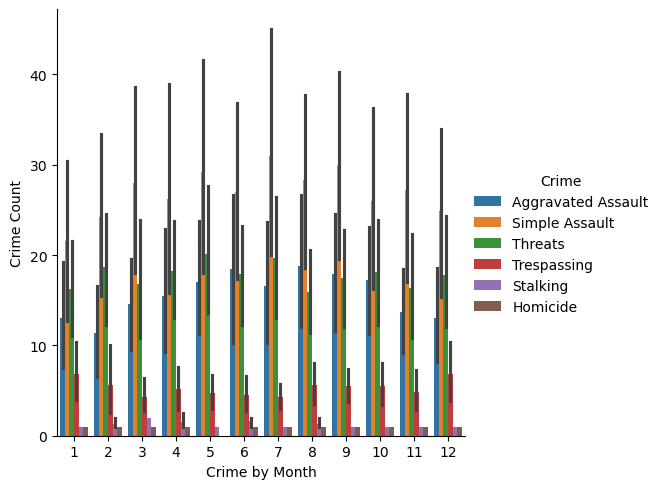

In [51]:
gcmndset = pd.DataFrame(gcmndset)
print(gcmndset)
g = sns.catplot(data=gcmndset, kind="bar",x="Date of Report",y="File Number",hue="Crime")
g.set_axis_labels("Crime by Month", "Crime Count")
plt.show()

### Group count crime by month per column: Neighborhood

In [52]:
gcnmdset = dset.groupby(["Neighborhood", dset["Date of Report"].dt.month, "Crime"]).count()["File Number"]
print(gcnmdset)

Neighborhood    Date of Report  Crime             
Agassiz         1               Aggravated Assault     3
                                Simple Assault         3
                                Threats                3
                                Trespassing            1
                2               Aggravated Assault     3
                                                      ..
West Cambridge  11              Trespassing            3
                12              Aggravated Assault     8
                                Simple Assault        39
                                Threats               18
                                Trespassing            3
Name: File Number, Length: 661, dtype: int64


### Plot bar graph / Count crime by month per neighborhood

['East Cambridge' 'North Cambridge' 'Cambridgeport' 'Riverside' 'Peabody'
 'Mid-Cambridge' 'Highlands' 'Strawberry Hill' 'Agassiz'
 'Inman/Harrington' 'Area 4' 'West Cambridge' 'MIT']


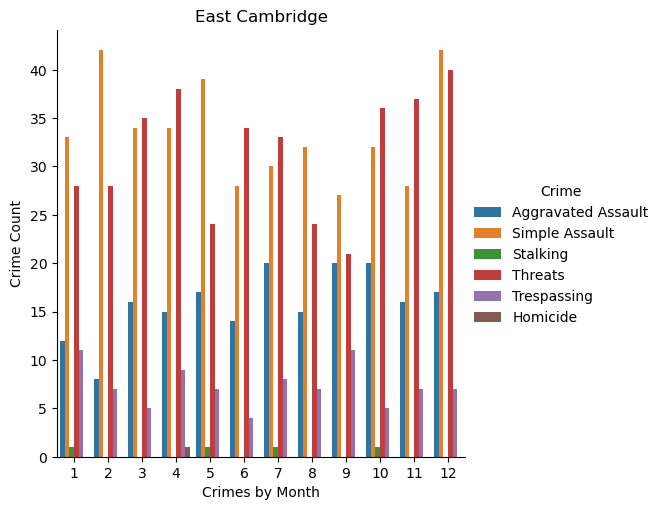

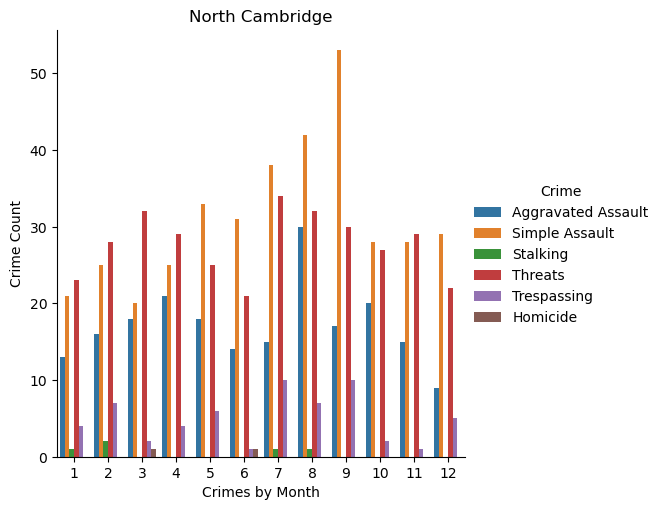

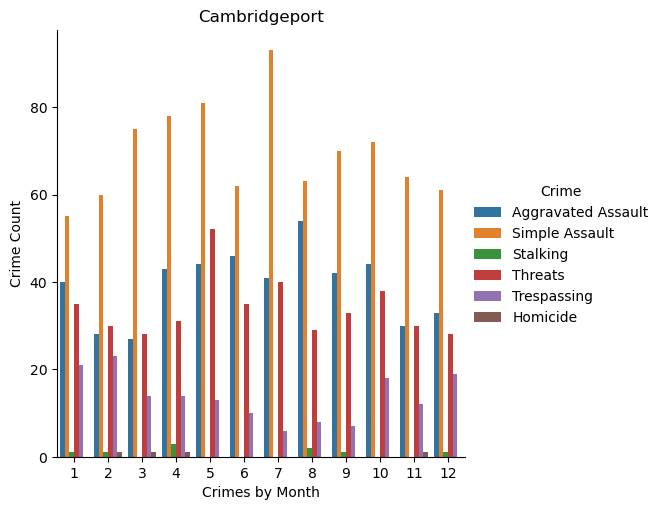

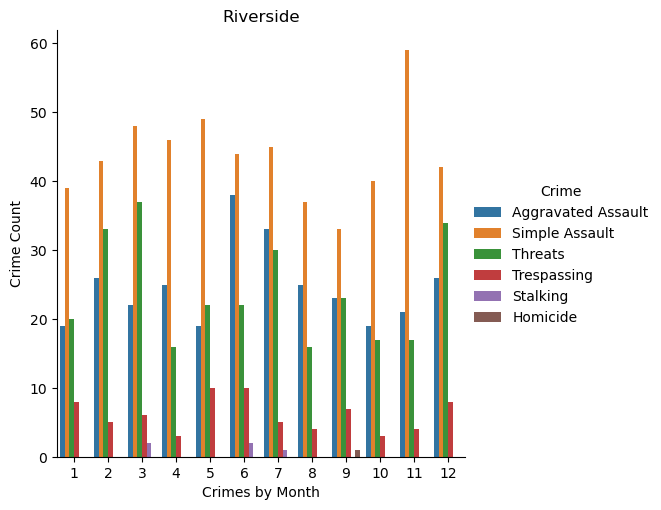

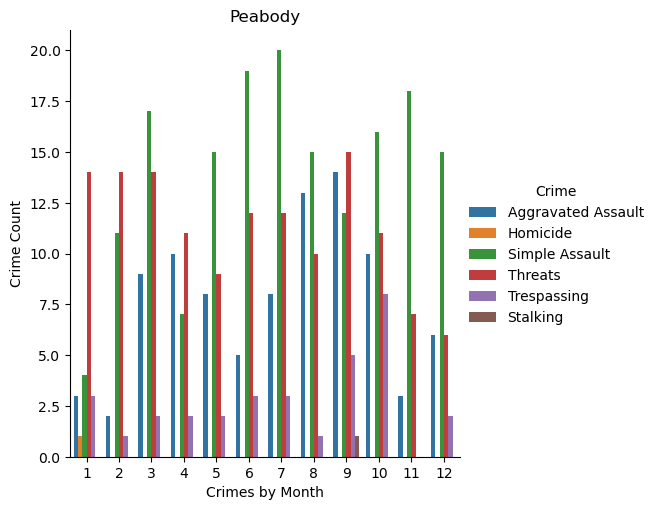

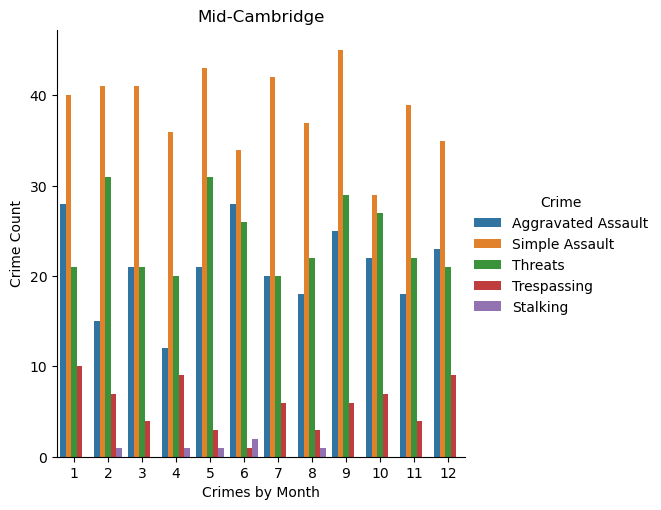

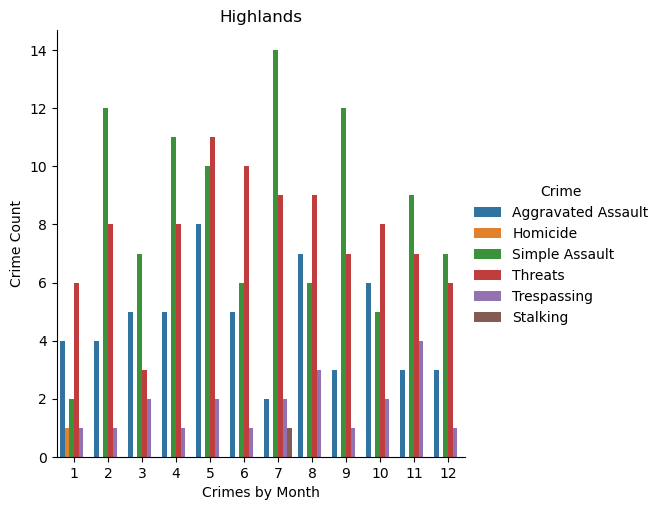

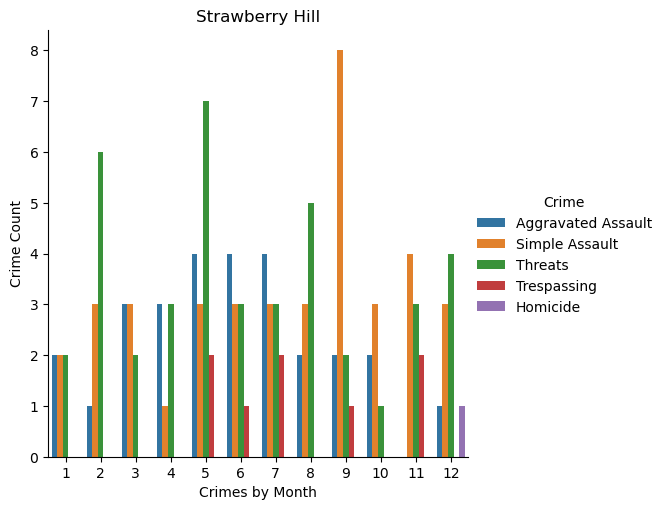

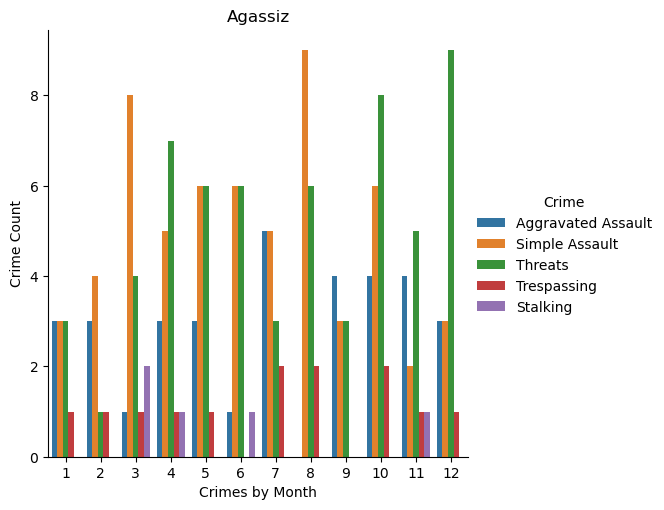

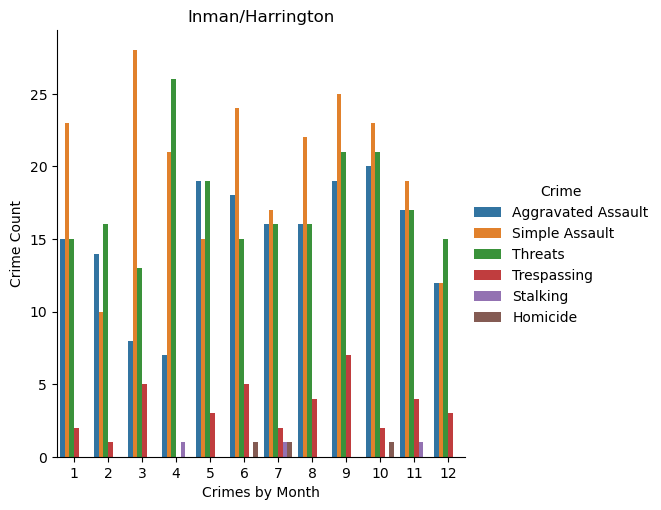

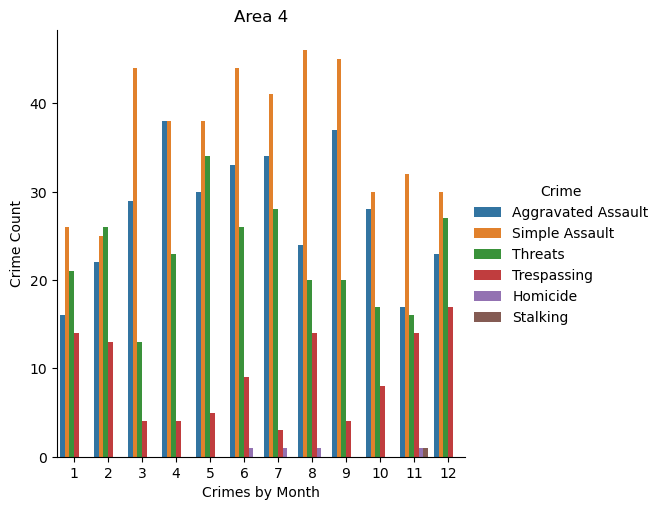

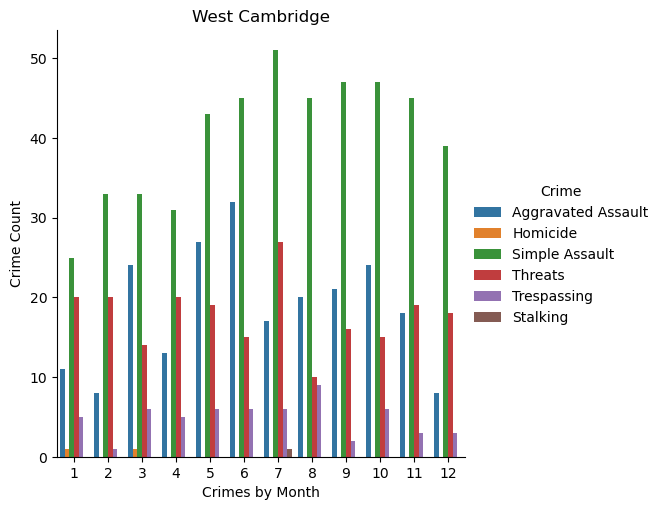

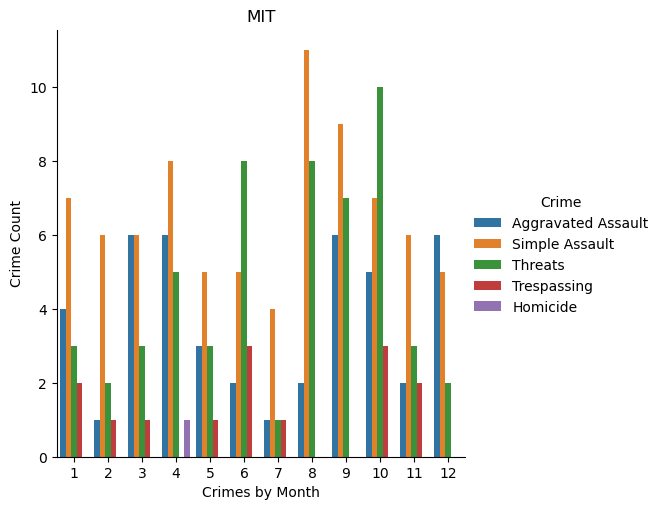

In [53]:
fd = dset['Neighborhood'].unique()
print(fd)
for fdn in fd:
    fn = gcnmdset.loc[fdn]
    g = sns.catplot(data=pd.DataFrame(fn), kind="bar",x="Date of Report",y="File Number",hue="Crime")
    g.set(title=fdn)
    g.set_axis_labels("Crimes by Month", "Crime Count")
    plt.show()

### Group count crime by type / Homicide Associated

In [54]:
gccdset = dset.groupby(["Crime"]).count()["File Number"]
print(gccdset)

Crime
Aggravated Assault    2402
Homicide                21
Simple Assault        4205
Stalking                41
Threats               2775
Trespassing            747
Name: File Number, dtype: int64


### Calculate mean by group crime type: Homicide associated

In [55]:
gccdset.mean()

1698.5

### Group count crime by neighborhood / Homicide Associated

In [56]:
gcncdset = dset.groupby(["Neighborhood"]).count()["File Number"]
print(gcncdset)

Neighborhood
Agassiz              173
Area 4              1155
Cambridgeport       1893
East Cambridge      1062
Highlands            271
Inman/Harrington     674
MIT                  193
Mid-Cambridge       1079
North Cambridge      977
Peabody              429
Riverside           1187
Strawberry Hill      117
West Cambridge       981
Name: File Number, dtype: int64


### Calculate mean / Crime by each neighborhood: Homicide associated

In [57]:
gcncdset.mean()

783.9230769230769

### Group count crime by year / Homicide Associated

In [58]:
gcydset = dset.groupby(dset["Date of Report"].dt.year).count()["File Number"]
display(pd.DataFrame(gcydset).sort_values(by="File Number"))

,File Number
Date of Report,
2024,365
2014,538
2016,571
2017,572
2013,601
2015,601
2020,606
2018,615
2019,641


### Calculate mean / Crime by each year: Homicide associated

In [59]:
gcymean = gcydset.mean().round(0).astype(int)
print(gcymean)

637


### Calculate mean - sum of squares / Crime by each year: Homicide associated

In [60]:
gcymeandiff = []
gcymeandiffsq = []
gcymdsqsum = 0
print("Mean differences")
for cyc in gcydset:
    md = cyc - gcymean
    gcymeandiff.append(md)
for c in gcymeandiff:
    print(c)
print("Mean differences squared")
for c in gcymeandiff:
    mdsq = c ** 2
    gcymeandiffsq.append(mdsq)
for s in gcymeandiffsq:
    gcymdsqsum += s
    print(s)
print("Sum of mean diff squared:", gcymdsqsum)

Mean differences
53
13
8
31
-36
-99
-36
-66
-65
-22
4
-31
54
133
330
-272
Mean differences squared
2809
169
64
961
1296
9801
1296
4356
4225
484
16
961
2916
17689
108900
73984
Sum of mean diff squared: 229927


### Calculate variance / Crime by each year: Homicide associated

In [61]:
#Count number of years from group crime by year data
gcydscount = gcydset.count()
print("Total number of years:",gcydscount)
#Calculate with variance formula -> sum of squared / (number of years - 1)
gcyvarnce = gcymdsqsum / gcydscount
print("Variance for crime by year (2009-2024):",gcyvarnce)
print("Variance round-off:",round(gcyvarnce,0).astype(int))

Total number of years: 16
Variance for crime by year (2009-2024): 14370.4375
Variance round-off: 14370


### Calculate Standard Deviation / Crime by each year: Homicide associated

In [62]:
# Square root of calculated variance
gcystdev = math.sqrt(gcyvarnce)
print("Standard Deviation for crime by year (2009-2024):",gcystdev)
print("Standard Deviation round-off:",int(round(gcystdev,0)))

Standard Deviation for crime by year (2009-2024): 119.8767596325493
Standard Deviation round-off: 120


In [63]:
gcydset.describe()

count     16.000000
mean     636.937500
std      123.808168
min      365.000000
25%      593.750000
50%      628.000000
75%      673.500000
max      967.000000
Name: File Number, dtype: float64

### Filter by specific neighborhood: Homicide associated

In [64]:
gcyndset = dset.loc[dset["Neighborhood"].isin(["Cambridgeport"])]
print(gcyndset)

      File Number      Date of Report                      Crime Date Time  \
13     2009-01423 2009-02-25 12:16:00             02/24/2009 12:15 - 12:30   
26     2009-01501 2009-02-28 07:52:00             02/28/2009 07:30 - 08:15   
42     2009-00409 2009-01-17 03:41:00                     01/17/2009 03:41   
111    2009-00107 2009-01-05 00:33:00             01/05/2009 00:20 - 00:30   
141    2009-00012 2009-01-01 12:43:00                     01/01/2009 14:05   
...           ...                 ...                                  ...   
95422  2009-01222 2009-02-17 20:26:00                     02/17/2009 21:26   
95577  2024-03752 2024-05-07 12:54:00  05/03/2024 15:47 - 05/07/2024 12:54   
95617  2024-01913 2024-03-07 15:45:00  03/01/2024 07:00 - 03/07/2024 15:45   
95839  2024-02990 2024-04-13 14:31:00                     04/13/2024 14:30   
95852  2024-04482 2024-05-29 22:37:00                     05/29/2024 22:36   

                    Crime  Reporting Area   Neighborhood  \
13 

### Filter crime count by year & month

In [65]:
# Stalking, Trespassing, Threats, Simple Assault, Aggravated Assault, Homicide
def set_crime_code(crime):
    if crime == "Stalking":
        return 1
    elif crime == "Trespassing":
        return 2
    elif crime == "Threats":
        return 3
    elif crime == "Simple Assault":
        return 4
    elif crime == "Aggravated Assault":
        return 5
    elif crime == "Homicide":
        return 6
    else:
        return 0

dset['Crime Code'] = dset.apply(lambda row: set_crime_code(row.Crime), axis = 1)
display(dset)
    

,File Number,Date of Report,Crime Date Time,Crime,Reporting Area,Neighborhood,Location,Crime Code
0,2009-01323,2009-02-21 09:53:00,02/21/2009 09:20 - 09:30,Threats,105.0,East Cambridge,"100 OTIS ST, Cambridge, MA",3
5,2009-01357,2009-02-22 21:39:00,02/22/2009 21:39 - 21:45,Aggravated Assault,1109.0,North Cambridge,"400 RINDGE AVE, Cambridge, MA",5
13,2009-01423,2009-02-25 12:16:00,02/24/2009 12:15 - 12:30,Simple Assault,501.0,Cambridgeport,"500 Massachusetts Ave, Cambridge, MA",4
17,2009-01436,2009-02-25 17:52:00,02/20/2009 00:10,Simple Assault,106.0,East Cambridge,"0 FULKERSON ST, Cambridge, MA",4
24,2009-01475,2009-02-26 10:10:00,02/26/2009 10:10,Threats,1109.0,North Cambridge,"400 RINDGE AVE, Cambridge, MA",3
...,...,...,...,...,...,...,...,...
95852,2024-04482,2024-05-29 22:37:00,05/29/2024 22:36,Simple Assault,504.0,Cambridgeport,"BROOKLINE ST & GREEN ST, Cambridge, MA",4
95856,2024-04506,2024-05-30 11:40:00,05/30/2024 10:49,Threats,903.0,Peabody,"1700 MASSACHUSETTS AVE, Cambridge, MA",3
95861,2024-03280,2024-04-23 13:52:00,04/23/2024 07:15 - 08:15,Threats,1204.0,Highlands,"200 Alewife Brook Pky, Cambridge, MA",3
95878,2024-03432,2024-04-28 09:53:00,04/28/2024 09:45 - 09:53,Simple Assault,1204.0,Highlands,"0 NEW ST, Cambridge, MA",4


### Group crime count by year, month, type

In [66]:
gcymcdset = dset.groupby([dset["Date of Report"].dt.year, dset["Date of Report"].dt.month, "Crime Code"]).count()["File Number"]
gcymcdset = pd.DataFrame(gcymcdset)
gcymcdset.columns = ["Crime Count"]
display(gcymcdset)

Crime Count
Date of Report Date of Report Crime Code             
2009           1              2                     5
                              3                     8
                              4                    21
                              5                    10
                              6                     1
...                                               ...
2024           4              5                    24
               5              2                     9
                              3                    29
                              4                    28
                              5                    18

[785 rows x 1 columns]

### Plot bar graph / Crime count by year, month, type

[2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024]


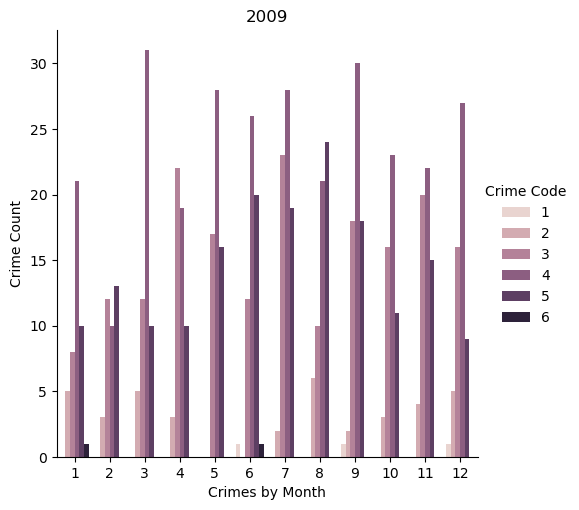

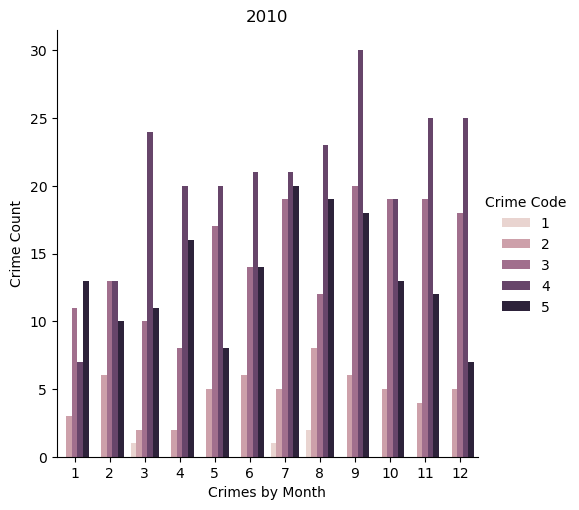

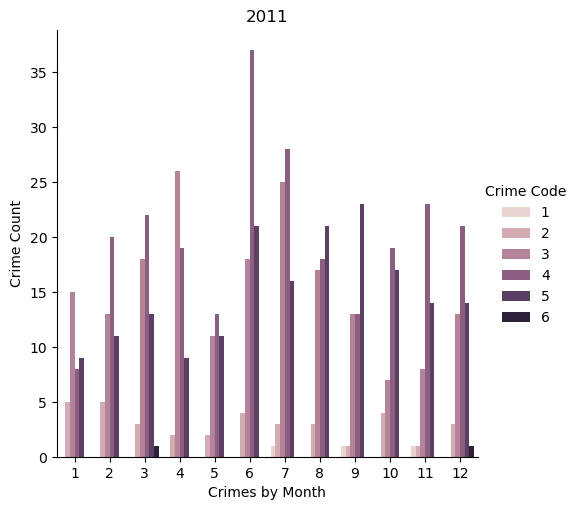

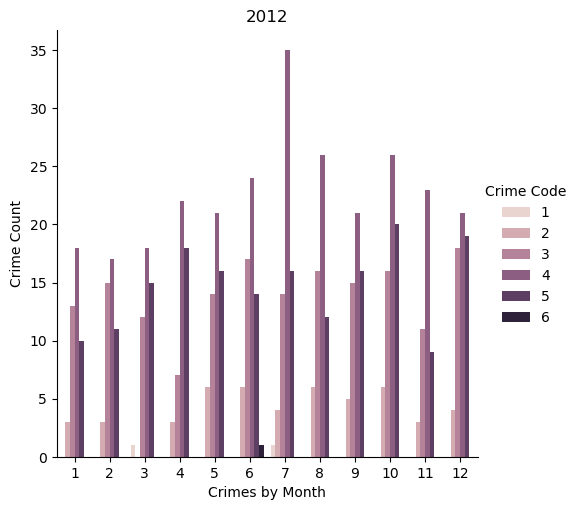

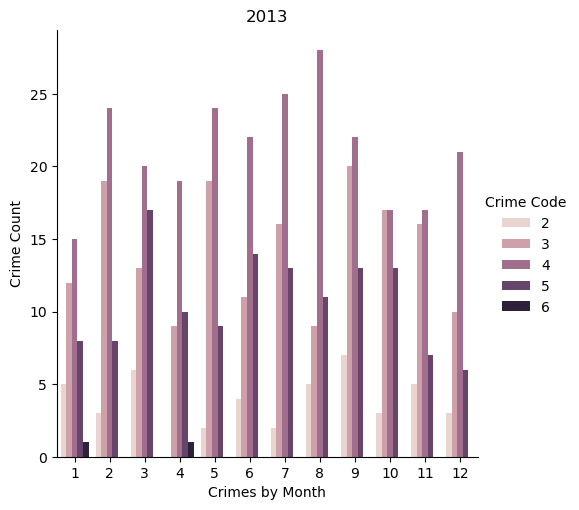

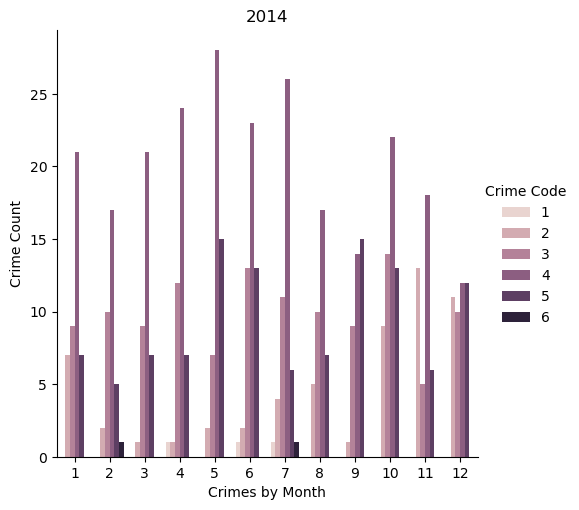

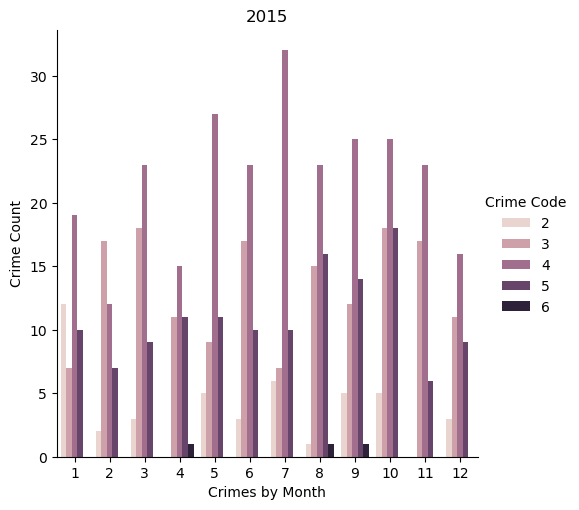

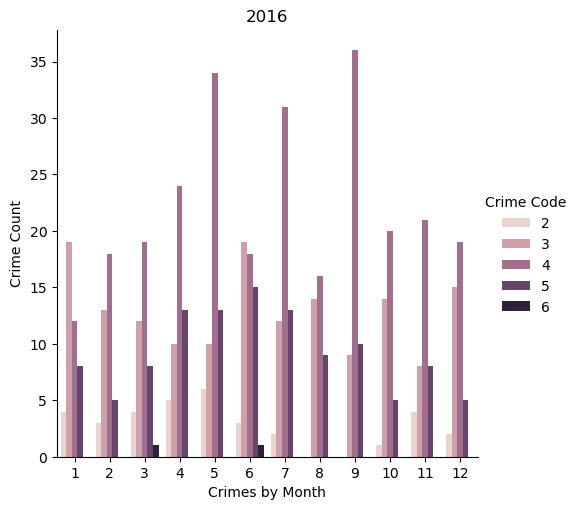

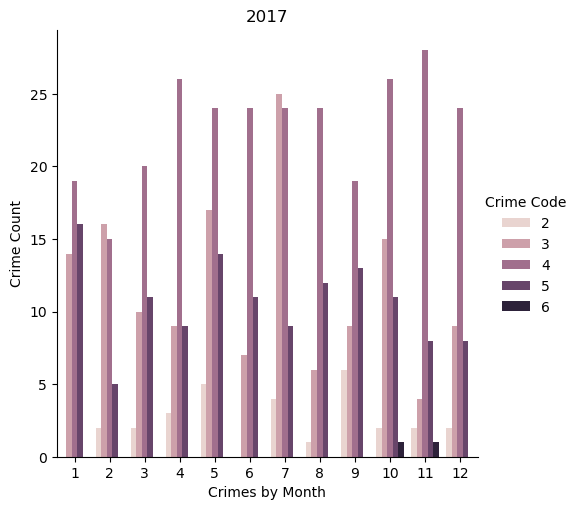

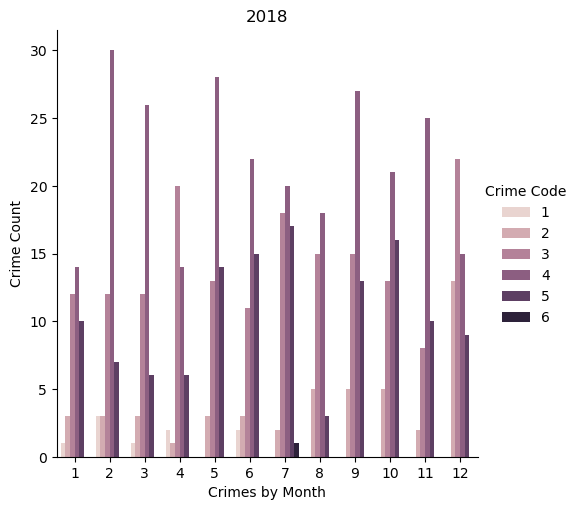

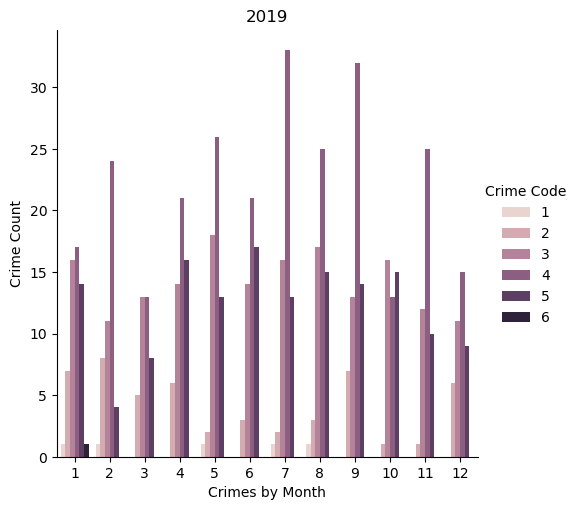

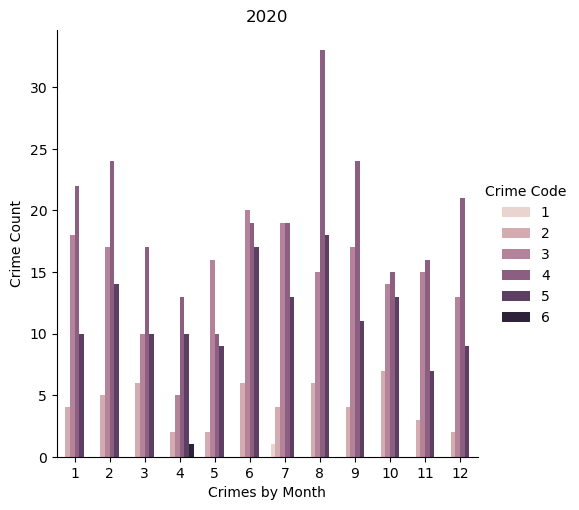

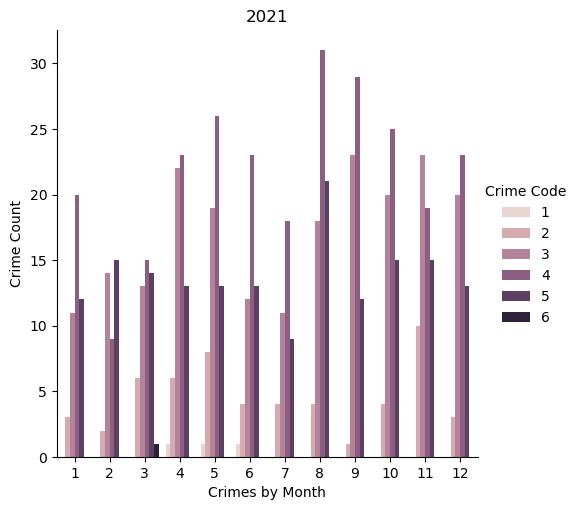

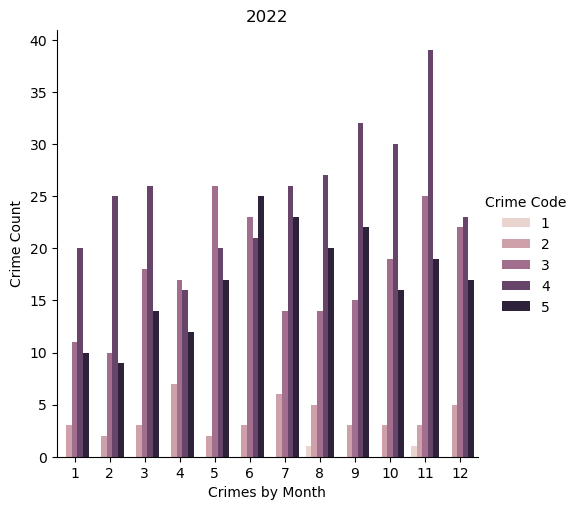

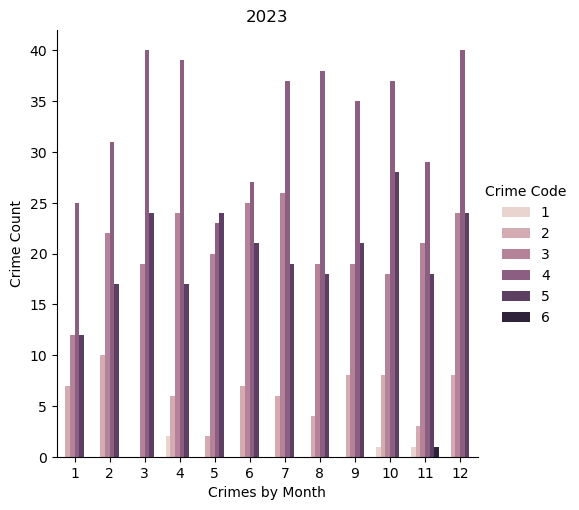

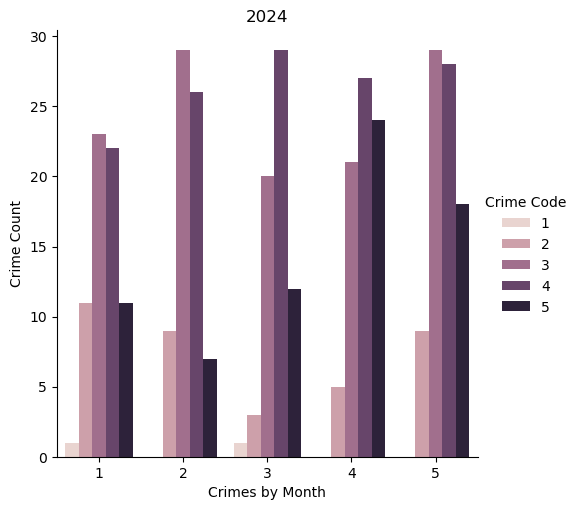

In [67]:
fyd = dset['Date of Report'].dt.year.unique()
print(fyd)
for fydn in fyd:
    fyn = gcymcdset.loc[fydn]
    g = sns.catplot(data=pd.DataFrame(fyn), kind="bar",x="Date of Report",y="Crime Count",hue="Crime Code")
    g.set(title=fydn)
    g.set_axis_labels("Crimes by Month", "Crime Count")
    plt.show()

### Export data to csv: Crime count by year, month, type

In [68]:
# display(gcymcdset)
# csv_file = 'gcymcdset.csv'
# gcymcdset.to_csv(csv_file)
# Read filtered new dataset
ndset = pd.read_csv("gcymcdset.csv")
ndset = pd.DataFrame(ndset)
display(ndset)

,Report_Year,Report_Month,Crime_Code,Crime_Count
0,2009,1,2,5
1,2009,1,3,8
2,2009,1,4,21
3,2009,1,5,10
4,2009,1,6,1
...,...,...,...,...
780,2024,4,5,24
781,2024,5,2,9
782,2024,5,3,29
783,2024,5,4,28


### Linear Regression Model
**Reference: https://www.gettingstarted.ai/applied-simple-linear-regression-model-using-python-for-beginners/**

### Build Model

In [69]:
# import scikit essentials for model
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [70]:
nds_selfeat = ["Report_Year","Report_Month","Crime_Code"]
X = ndset[nds_selfeat].values
y = ndset["Crime_Count"].values
# print(X)
# print(y)

# Assign train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=48)

### Plot graphs from prepared training data

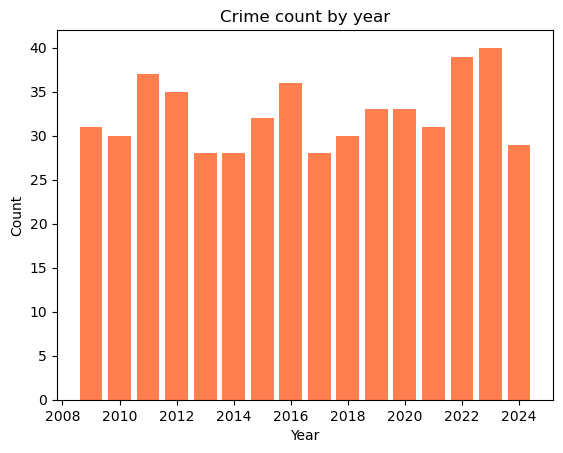

In [71]:
plt.bar(ndset["Report_Year"], y, color="coral")
plt.title("Crime count by year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

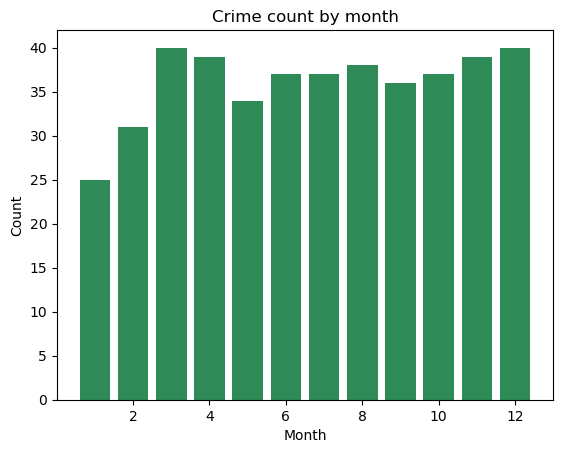

In [72]:
plt.bar(ndset["Report_Month"], y, color="seagreen")
plt.title("Crime count by month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

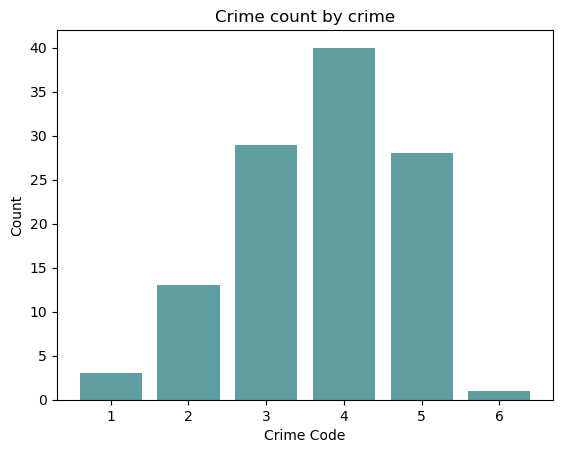

In [73]:
plt.bar(ndset["Crime_Code"], y, color="cadetblue")
plt.title("Crime count by crime")
plt.xlabel("Crime Code")
plt.ylabel("Count")
plt.show()

### Fit model / Linear Regression

In [78]:
from sklearn.linear_model import LinearRegression
#from sklearn.metrics import r2_score
#create model object
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Get intercept & slope from model

In [75]:
print("Intercept (Beta 0):",model.intercept_)
print("Slope (Beta 1):",model.coef_[0])

Intercept (Beta 0): -498.07248492990806
Slope (Beta 1): 0.24767662859893083


### Check model accuracy

In [79]:
rsq = model.score(X_test, y_test)
print(f"R Squared: {rsq:.2f}")

R Squared: 0.13


### Make Prediction

In [ ]:
# predict aggravated assault crime count for year 2024, months 6, 7 & 8
nc_data = [[2024,6,5], [2024,7,5], [2024,8,5], [2024,4,5]]
pred_cc = model.predict(nc_data)

for feat, count in zip(nc_data, pred_cc):
    print(f'year: {feat[0]}, month: {feat[1]}, code: {feat[2]} => crime_count: {count}')

### Random Forest Model
**Reference: https://github.com/Geoffrey-lab/Random-Forest-Regression-An-Introduction**  
**Reference: https://towardsdatascience.com/random-forest-in-python-24d0893d51c0/**

### Build Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Split training data
nds_selfeat = ["Report_Year","Report_Month","Crime_Code"]
X = ndset[nds_selfeat].values
y = ndset["Crime_Count"].values

# Assign train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=48)

# Train model
forest = RandomForestRegressor(n_estimators=200, max_depth=5)
forest.fit(X_train, y_train)

### Test model / Plot graph from test

In [ ]:
#test model
y_pred = forest.predict(X_test)
errors = abs(y_pred - y_test) #absolute error
print('Mean Absolute Error:', round(np.mean(errors), 2)) #mean absolute error
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred))) #numpy square root, find mean squared error
mape = 100 * (errors / y_test) #mean absolute percentage error
accuracy = 100 - np.mean(mape) #calculate model accuracy
print('Accuracy:', round(accuracy, 2), '%.')

#plot graph
f, ax = plt.subplots(figsize=(5, 5))
ax.set_title('Actual vs Predicted')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.scatter(y_test, y_pred, color="orchid")
ax.plot(y_test, y_test, color="olive")
plt.show()

### Make Prediction

In [ ]:
# Predict
nc_data = [[2024,5,5],[2024,6,5], [2024,7,5], [2024,8,5]]
pred_cc = forest.predict(nc_data)

for feat, count in zip(nc_data, pred_cc):
    print(f'year: {feat[0]}, month: {feat[1]}, code: {feat[2]} => crime_count: {count:.2f}')

### Optimize training / Train more models

In [ ]:
#optimizing training
forest_1 = RandomForestRegressor(n_estimators=25, max_depth=5, random_state=20)
forest_2 = RandomForestRegressor(n_estimators=75, max_depth=5, random_state=20)
forest_3 = RandomForestRegressor(n_estimators=150, max_depth=5, random_state=20)

forest_1.fit(X_train, y_train)
forest_2.fit(X_train, y_train)
forest_3.fit(X_train, y_train)

### Test optimized models / Plot graph from test

In [ ]:
f, ax = plt.subplots(figsize=(15, 5), nrows=1, ncols=3, sharey=True)

pred = [forest_1.predict(X_test), forest_2.predict(X_test), forest_3.predict(X_test)]
title = ['trees = 25', 'trees = 75', 'trees = 150']

for i in range(3):
    rmse = round(np.sqrt(mean_squared_error(pred[i], y_test)))
    ax[i].set_title(title[i] + " | (RMSE: " + str(rmse) + ")")
    ax[i].set_xlabel('Actual')
    ax[i].set_ylabel('Predicted')
    ax[i].scatter(y_test, pred[i],color='seagreen')
    ax[i].plot(y_test, y_test, color='crimson')
plt.show()

### Make prediction / Optimized Models

In [ ]:
#predict with optimized models

nc_data = [[2024,5,5],[2024,6,5], [2024,7,5], [2024,8,5]]

# Predict using Forest_1
pred1_cc = forest_1.predict(nc_data)

print("Forest 1 model")
for feat, count in zip(nc_data, pred1_cc):
    print(f'year: {feat[0]}, month: {feat[1]}, code: {feat[2]} => crime_count: {count:.2f}')

# Predict using Forest_2
pred2_cc = forest_2.predict(nc_data)

print("Forest 2 model")
for feat, count in zip(nc_data, pred2_cc):
    print(f'year: {feat[0]}, month: {feat[1]}, code: {feat[2]} => crime_count: {count:.2f}')

# Predict using Forest_3
pred3_cc = forest_2.predict(nc_data)

print("Forest 3 model")
for feat, count in zip(nc_data, pred3_cc):
    print(f'year: {feat[0]}, month: {feat[1]}, code: {feat[2]} => crime_count: {count:.2f}')